# Retail Sales Analytics

## Project Overview

This project is a small first portfolio project developed as part of my transition
into the Data Analyst field. The project focuses on the analysis of retail sales
data to exploring sales performance, product categories, customer
characteristics, and revenue trends.

The analysis covers data quality assessment, exploratory data analysis (EDA),
data visualization, and the extraction of business insights from the results.

## Objectives

- Analyze overall sales performance
- Compare product categories
- Explore customer demographics
- Identify temporal sales patterns
- Extract actionable business insights

## Business Questions

1. Which product categories generate the most revenue?
2. Which categories have the highest sales volume?
3. How does customer spending vary by gender and age group?
4. How does revenue evolve over time?
5. Are changes in revenue associated with changes in sales volume?

### Data Loading

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")

print("Path to dataset files:", path)

C:\Users\alves\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\alves\.cache\kagglehub\datasets\mohammadtalib786\retail-sales-dataset\versions\1


In [2]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

### Data Quality Assessment


In [3]:
# Explore the dataset

df = pd.read_csv(path + "/retail_sales_dataset.csv")
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [4]:
# See the dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


**Initial data inspection:** The dataset contains 1,000 transactions and 9 variables. No missing values were identified. The Date column was initially stored as string and was converted to datetime.

In [5]:
# See if exists any duplicate rows in the dataset
duplicate_rows = df[df.duplicated()]

print("Number of duplicate rows:", duplicate_rows.shape[0])

Number of duplicate rows: 0


No duplicates row were identified in the dataset.

In [6]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# see value counts for categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print("Value counts for categorical columns:")
for column in categorical_columns:
    print(f"\n{column} value counts:")
    print(df[column].value_counts())

Value counts for categorical columns:

Customer ID value counts:
Customer ID
CUST001     1
CUST002     1
CUST003     1
CUST004     1
CUST005     1
           ..
CUST996     1
CUST997     1
CUST998     1
CUST999     1
CUST1000    1
Name: count, Length: 1000, dtype: int64

Gender value counts:
Gender
Female    510
Male      490
Name: count, dtype: int64

Product Category value counts:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


The categorical columns did not present inconsistent representations.

In [8]:
# Confirm impossible values in the dataset

# negative age values
negative_age = df[df['Age'] < 0]

# negative price values
negative_price = df[df['Price per Unit'] < 0]

# negative quantity values
negative_quantity = df[df['Quantity'] < 0]

# total amount diferent from price * quantity
total_amount_different = df[df['Total Amount'] != df['Price per Unit'] * df['Quantity']]

print("Number of negative age values:", negative_age.shape[0])
print("Number of negative price values:", negative_price.shape[0])
print("Number of negative quantity values:", negative_quantity.shape[0])
print("Number of total amount different from price * quantity:", total_amount_different.shape[0])

Number of negative age values: 0
Number of negative price values: 0
Number of negative quantity values: 0
Number of total amount different from price * quantity: 0


No negative values were found in age, quantity or unit price, the total amount was consistent with quantity multiplied by unit price.

In [9]:
# verify key columns are unique
print("Customer ID is unique:", df['Customer ID'].is_unique)
print("Transaction ID is unique:", df['Transaction ID'].is_unique)

# verify key columns are unique using nunique
print("Customer ID is unique:", df['Customer ID'].nunique())
print("Transaction ID is unique:", df['Transaction ID'].nunique())


Customer ID is unique: True
Transaction ID is unique: True
Customer ID is unique: 1000
Transaction ID is unique: 1000


Transaction ID is unique, meaning each transaction has a unique identifier. 

Customer ID is also unique in this dataset, meaning each customer appears only once and therefore each customer has only one transaction.

In [10]:
# Let´s see the temporal distribution of the sales data.
print("Temporal distribution of the sales data:")
print(df['Date'].describe())

Temporal distribution of the sales data:
count                          1000
mean     2023-07-03 00:25:55.200000
min             2023-01-01 00:00:00
25%             2023-04-08 00:00:00
50%             2023-06-29 12:00:00
75%             2023-10-04 00:00:00
max             2024-01-01 00:00:00
Name: Date, dtype: object


In [11]:
# see if exists outliers in the dataset
print("Outliers in the dataset:")
for column in df.select_dtypes(include=[np.number]).columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers")


Outliers in the dataset:
Transaction ID: 0 outliers
Age: 0 outliers
Quantity: 0 outliers
Price per Unit: 0 outliers
Total Amount: 0 outliers


No outliers were identified using the IQR method. Therefore, no observations were removed based on this criterion.

### Exploratory Data Analysis

#### Descriptive Statistics

In [12]:
# Descritive statistics for numeric columns
numeric_columns = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
print("Descriptive statistics for numeric columns:")
print(df[numeric_columns].describe())


Descriptive statistics for numeric columns:
              Age     Quantity  Price per Unit  Total Amount
count  1000.00000  1000.000000     1000.000000   1000.000000
mean     41.39200     2.514000      179.890000    456.000000
std      13.68143     1.132734      189.681356    559.997632
min      18.00000     1.000000       25.000000     25.000000
25%      29.00000     1.000000       30.000000     60.000000
50%      42.00000     3.000000       50.000000    135.000000
75%      53.00000     4.000000      300.000000    900.000000
max      64.00000     4.000000      500.000000   2000.000000


 - Based on the descriptive statistics, we can see that regarding age, the minimum age of a customer is 18 years. 
 - The average quantity sold is approximately 2 to 3 units per transaction, with a maximum of 4 units. 
 - The average unit price is €179, resulting in an average transaction value of approximately €456.

#### Product Analysis

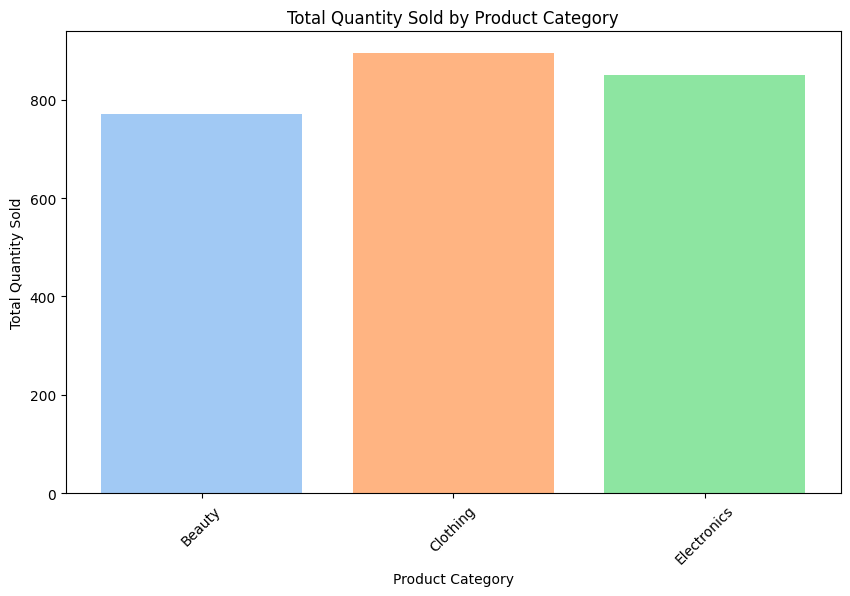

In [31]:
# category for quantity sold
total_quantity_by_category = df.groupby('Product Category')['Quantity'].sum()

plt.figure(figsize=(10, 6))
plt.bar(total_quantity_by_category.index, total_quantity_by_category.values, color=sns.color_palette('pastel', len(total_quantity_by_category)))
plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()

In [14]:
# product category with the highest total sales
total_sales_by_category = df.groupby('Product Category')['Total Amount'].sum()

print("Product category with the highest total sales:", total_sales_by_category.idxmax())
print("Product category with the lowest total sales:", total_sales_by_category.idxmin())
print("Total sales by product category:")
print(total_sales_by_category)

Product category with the highest total sales: Electronics
Product category with the lowest total sales: Beauty
Total sales by product category:
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


Although Clothing has the highest sales volume in terms of units sold, Electronics generates the highest total revenue. This difference suggests that Electronics products have a higher average price per unit, allowing the category to generate more revenue despite selling fewer units.

In [15]:
# mean price per unit by product category
mean_price_by_category = df.groupby('Product Category')['Price per Unit'].mean()
print("Mean price per unit by product category:")
print(mean_price_by_category)

Mean price per unit by product category:
Product Category
Beauty         184.055375
Clothing       174.287749
Electronics    181.900585
Name: Price per Unit, dtype: float64


The average unit price of Electronics products is slightly higher than that of Clothing products. Although Clothing sells more units, the higher average unit price of Electronics contributes to its higher total revenue. Beauty has the highest average unit price despite having the lowest sales volume.


#### Customer Analysis

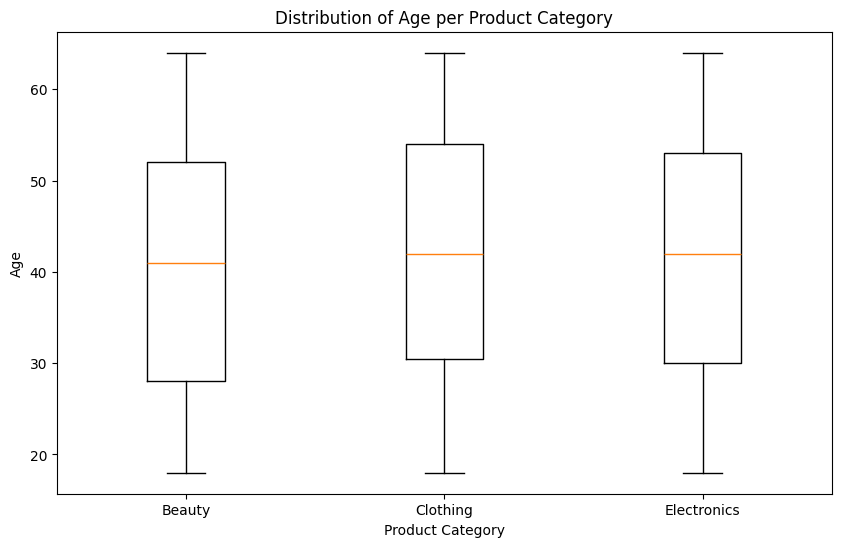

In [33]:
# distribution age per product category
plt.figure(figsize=(10, 6))
plt.boxplot([df[df['Product Category'] == category]['Age'] for category in df['Product Category'].unique()], labels=df['Product Category'].unique())
plt.title('Distribution of Age per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Age')
plt.show()

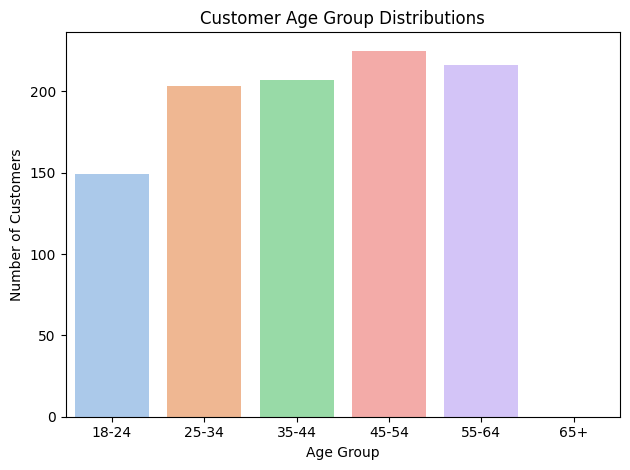

In [27]:
# see age distribution
Age_bins = [18, 25, 35, 45, 55, 65, np.inf]
Age_labels = [ '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=Age_bins, labels=Age_labels, right=False)

age_counts = df['Age Group'].value_counts().sort_index()
sns.barplot(x=age_counts.index, y=age_counts.values,palette='pastel')
plt.title("Customer Age Group Distributions")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


Regarding the age distribution by product category, the majority of customers are concentrated in the adult age range, with most observations occurring approximately between 28 and 55 years old.

As for the distribution by age range, we observed that the majority of customers are in the 45-54 age range, followed by the 55-64 age range.

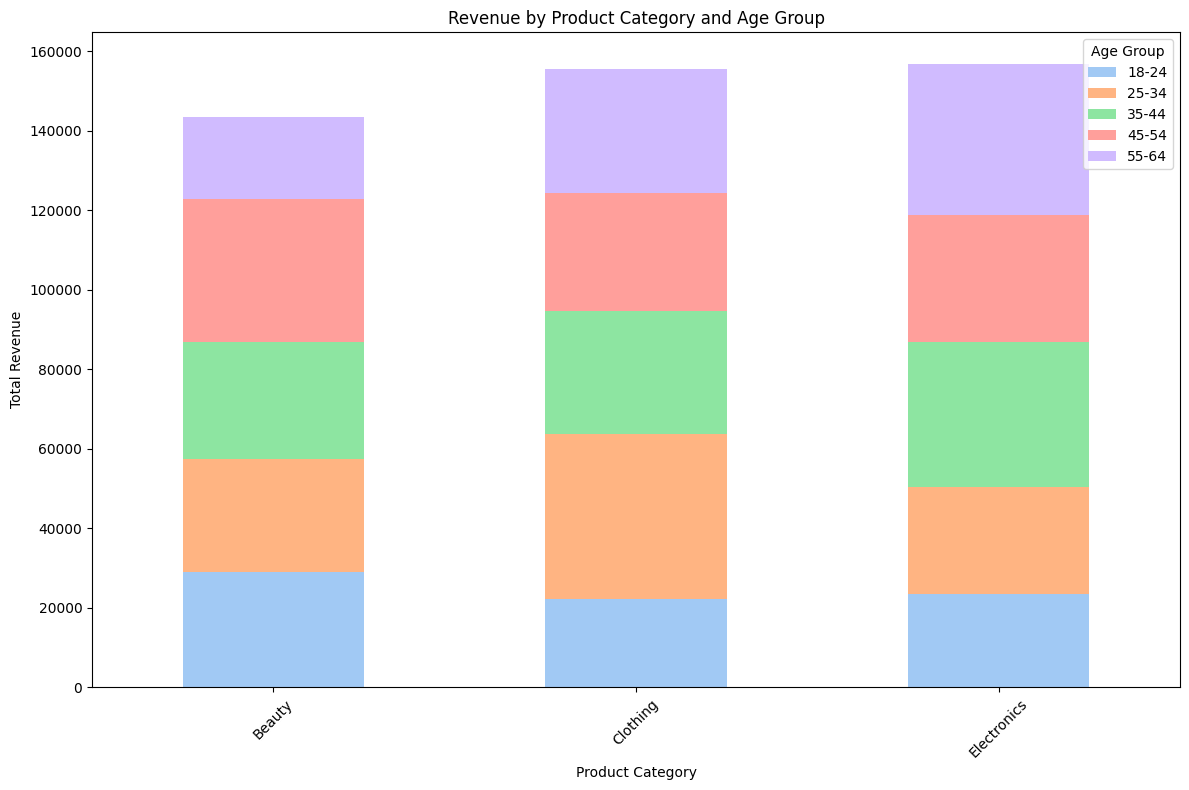

In [35]:
# Revenue by product category and age group 
revenue_by_category_age_group = df.groupby(['Product Category', 'Age Group'])['Total Amount'].sum().unstack()
revenue_by_category_age_group.plot(kind='bar', stacked=True, figsize=(12, 8), color=sns.color_palette('pastel', len(revenue_by_category_age_group.columns)))
plt.title('Revenue by Product Category and Age Group')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

In the 'Beauty' category, the highest spending age group is 45-54, while in 'Clothing' it's 25-34. In the 'Electronics' category, spending is more stable, remaining similar from 35 to 64.

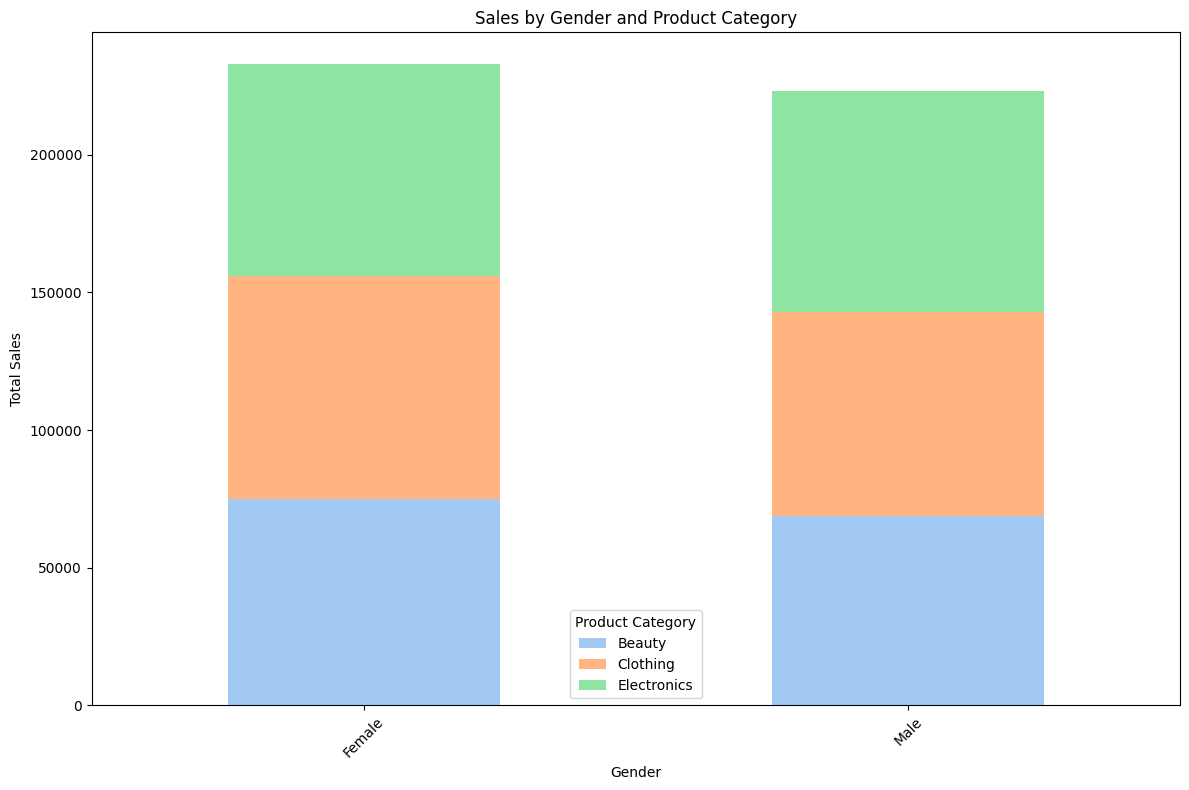

In [36]:
# sales by gender and product category
sales_by_gender_category = df.groupby(['Gender', 'Product Category'])['Total Amount'].sum().unstack()
sales_by_gender_category.plot(kind='bar', stacked=True, figsize=(12, 8),color=sns.color_palette('pastel', len(sales_by_gender_category.columns)))
plt.title('Sales by Gender and Product Category')
plt.xlabel('Gender')
plt.ylabel('Total Sales')  
plt.xticks(rotation=45)
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()

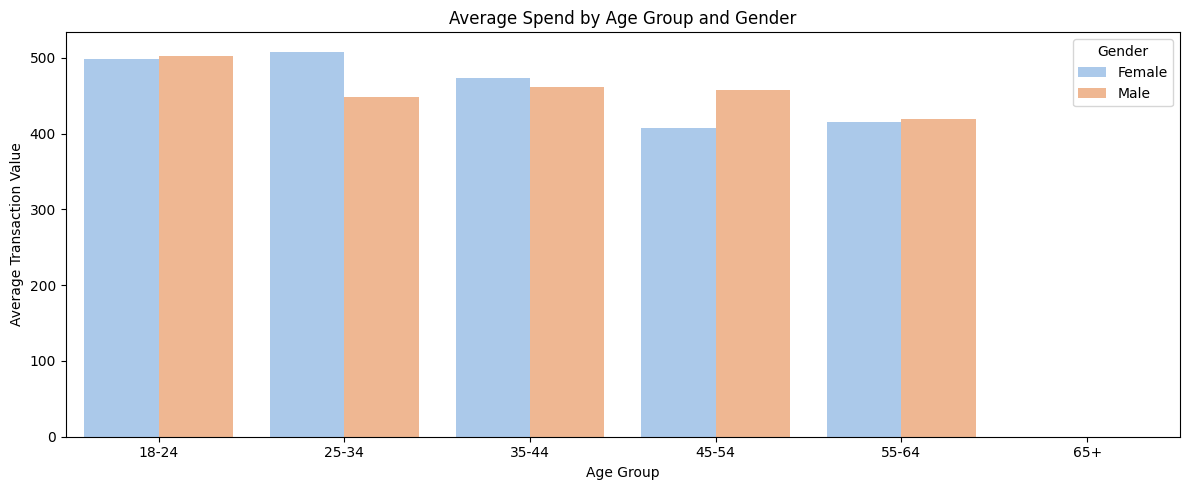

In [37]:
# see gender distribution per age group
plt.figure(figsize=(12,5))
age_gender_spend = df.groupby(['Age Group', 'Gender'])['Total Amount'].mean().reset_index()
sns.barplot(
    data=age_gender_spend,
    x='Age Group',
    y='Total Amount',
    hue='Gender',
    palette='pastel'
)
plt.title("Average Spend by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel('Average Transaction Value')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

Female customers generated a higher total revenue than male customers. The dataset contains 510 female and 490 male customers, indicating a slightly higher representation of female customers. By category, the distribution is almost the same, so there is not much difference in spending between genders, with lower spending on beauty products.

Regarding transaction values, we can observe that both male and female customers show a high transaction value in the 18-24 age range. The difference lies in the fact that the 45-54 and 55-64 age ranges, which represent the majority of customers, are those with the lowest transaction value, especially among female customers in the 45-54 age range.

In [20]:
average_spending_gender = df.groupby('Gender')['Total Amount'].mean()

print(average_spending_gender)

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


Based on the average spending, female customers generated higher total revenue because they spent more per transaction than male customers.

#### Temporal Analysis

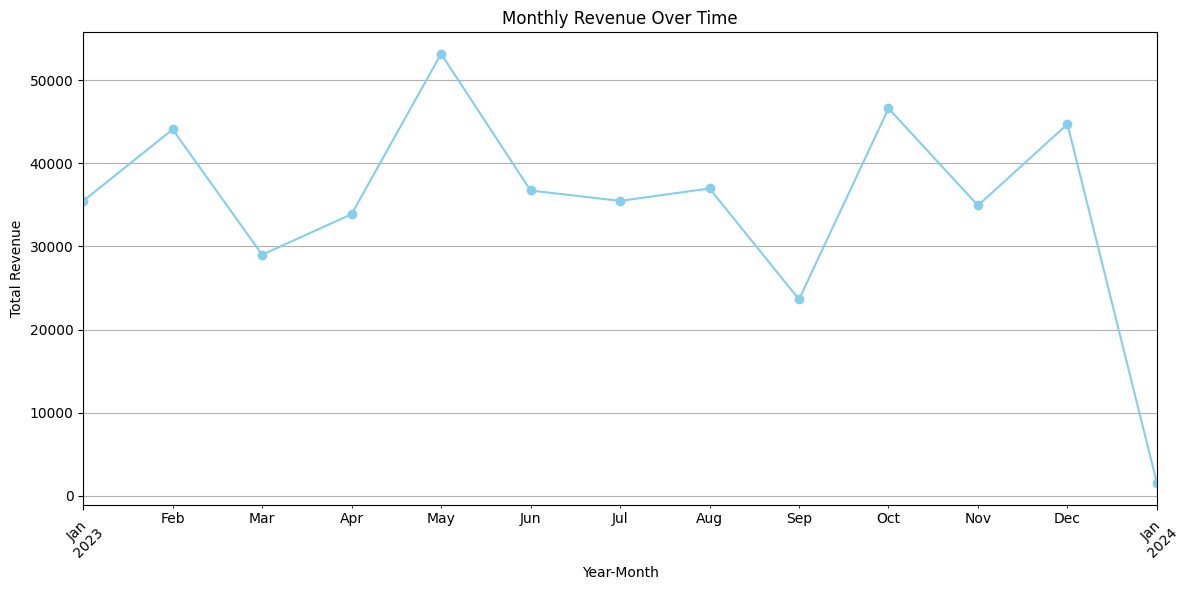

In [38]:
# Temporal analysis of sales data
# Group the data by month and year, and calculate the total sales for each month
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['Total Amount'].sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='skyblue')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

There is a peak in monthly revenue in May, exceeding €50,000, followed by a sharp decline towards the end of the year.

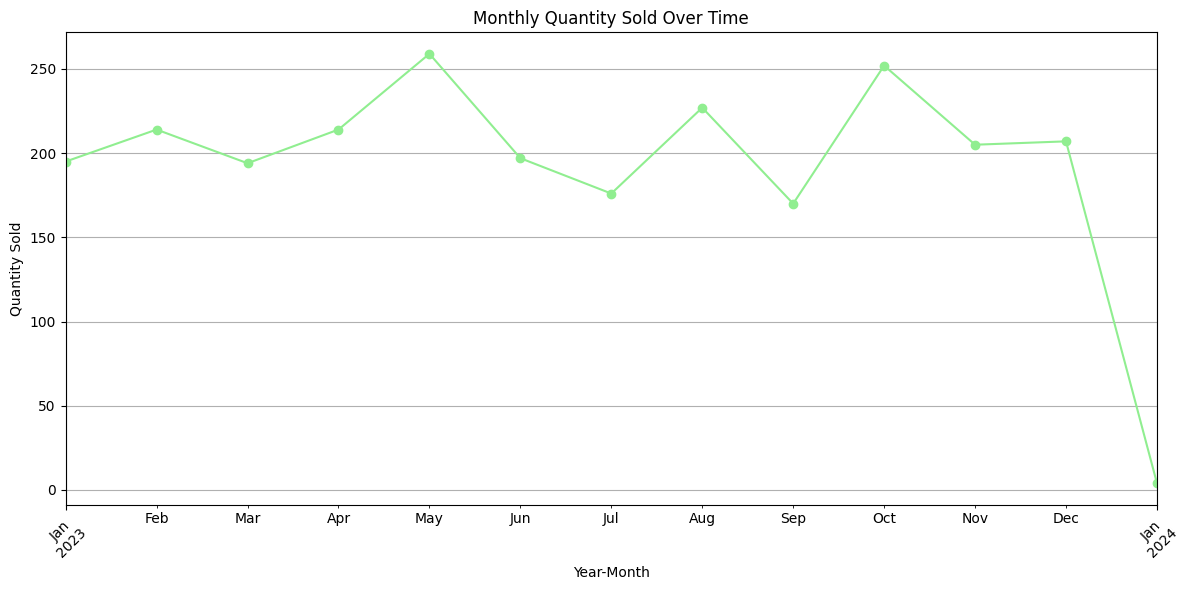

In [39]:
# Temporal analysis of quantity sold data
# Group the data by month and year, and calculate the total quantity sold for each month
monthly_quantity = df.groupby('YearMonth')['Quantity'].sum()

plt.figure(figsize=(12, 6))
monthly_quantity.plot(kind='line', marker='o', color='lightgreen')
plt.title('Monthly Quantity Sold Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

As shown in the monthly quantity sold chart, there is a peak in May, with more than 250 units sold, followed by another increase in October, with approximately 200 units sold. Unlike the revenue trend, which increases from November to December, the quantity of units sold remains relatively stable during this period.

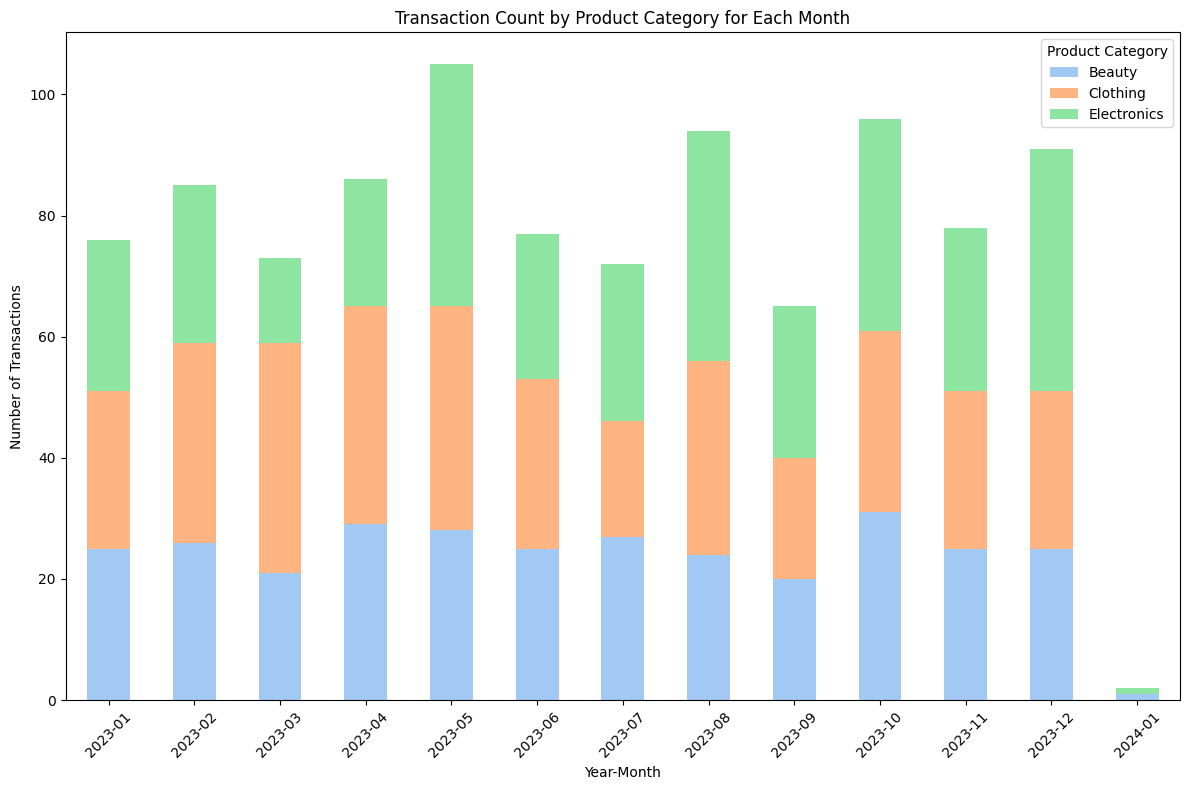

In [40]:
# Transaction number by product category for each month
transaction_count_by_category_month = df.groupby(['YearMonth', 'Product Category'])['Transaction ID'].nunique().unstack()
transaction_count_by_category_month.plot(kind='bar', stacked=True, figsize=(12, 8), color=sns.color_palette('pastel', len(transaction_count_by_category_month.columns)))
plt.title('Transaction Count by Product Category for Each Month')
plt.xlabel('Year-Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()

Electronics transactions show higher volumes in May, August, October, and December compared with the other months.

#### Correlation Analysis

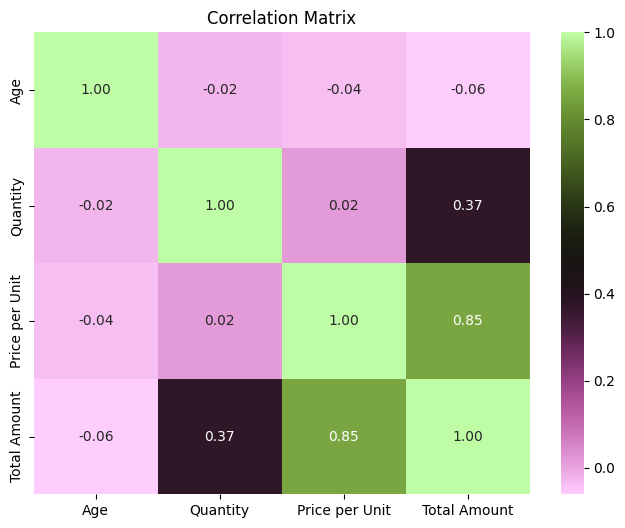

In [44]:
# Correlation analysis between numeric columns
correlation_matrix = df[numeric_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='vanimo', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

The strong correlations between Total Amount and Quantity/Price per Unit are expected because Total Amount is directly calculated as Quantity × Price per Unit. Therefore, these correlations should not be interpreted as independent business relationships.

### Initial Business Insights

1. Although Clothing has the highest sales volume in terms of units sold, Electronics generates the highest total revenue. Electronics has a slightly higher average unit price than Clothing, which allows it to generate more revenue despite selling fewer units. Beauty has the highest average unit price despite having the lowest sales volume.

2. Although the dataset contains a slightly higher representation of female customers (510 versus 490 male customers), female customers also have a higher average spending per transaction. Therefore, their higher total revenue is not only explained by their slightly greater representation in the dataset.

3. Customer ages are mainly concentrated among adults, with most observations falling approximately between 28 and 55 years old. Different age groups show different spending patterns across categories: Beauty has the highest spending among customers aged 45–54, Clothing among those aged 25–34, while Electronics shows a more stable spending distribution among customers aged 35–64.

4. There was a peak in revenue in May, exceeding €50,000, accompanied by a peak of more than 250 units sold. In contrast, between November and December, revenue increased while the quantity of products sold remained relatively stable. This suggests that the increase in revenue during this period was not driven by a significant increase in sales volume.

### Conclusions

- Clothing has the highest sales volume in terms of units sold, while Electronics generates the highest total revenue.
- Female customers have a higher average spending per transaction than male customers.
- Customer spending is mainly concentrated among adults, with the main patterns observed between approximately 28 and 55 years old.
- May shows the highest monthly revenue and one of the highest sales volumes in terms of units sold.
- Revenue and sales volume do not always follow the same pattern, particularly towards the end of the year.
- The correlation analysis shows strong relationships between Total Amount and both Quantity and Price per Unit, which is expected because Total Amount is directly calculated from these two variables.

In [ ]:
# save the cleaned dataset to a new CSV file to this path
save_path = ".../data/cleaned_retail_sales_dataset.csv"
df.to_csv(save_path, index=False)